<a href="https://colab.research.google.com/github/HakumenWorld/Digital-Skola/blob/main/%5BFebi_Kristiana_Conqueror_Project_2_DS_Batch60%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Segmentation dengan K-Means, PCA, dan Cluster Profiling**


## 1. Persiapan library

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2. Membaca data

Notebook akan mencari CSV secara otomatis. Di Google Colab, unggah file CSV saat kotak unggah muncul apabila file belum tersedia di folder `/content`.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
path_to_file = '/content/drive/MyDrive/Digital Skola/CP 2/Segmentation.csv'  # Sesuaikan dengan path file CSV Anda

try:
    customer_info = pd.read_csv(path_to_file)
    print(f"File dibaca dari: {path_to_file.split('/')[-1]}")
    print(f"Dimensi dataset: {customer_info.shape[0]:,} baris × {customer_info.shape[1]:,} kolom")
except FileNotFoundError:
    print(f"File tidak ditemukan di: {path_to_file}")
    print("Pastikan file 'segmentation_data.csv' ada di root Google Drive Anda atau sesuaikan path_to_file.")
except Exception as e:
    print(f"Terjadi kesalahan saat membaca file: {e}")

File dibaca dari: Segmentation.csv
Dimensi dataset: 2,000 baris × 8 kolom


In [9]:
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


In [10]:
customer_info.isnull().sum()

,0
ID,0
Sex,0
Marital status,0
Age,0
Education,0
Income,0
Occupation,0
Settlement size,0


In [11]:
customer_info.duplicated().sum()

np.int64(0)

In [12]:
customer_info.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


In [13]:
customer_info.drop(columns='ID', axis=1, inplace=True)

In [15]:
df = customer_info.copy()

In [16]:
DECODE = {
    'Sex'            : {0: 'Female',      1: 'Male'},
    'Marital status' : {0: 'Single',      1: 'Married'},
    'Education'      : {0: 'Other',       1: 'High School', 2: 'University', 3: 'Graduate'},
    'Occupation'     : {0: 'Unemployed',  1: 'Skilled',     2: 'Highly Qualified'},
    'Settlement size': {0: 'Small City',  1: 'Mid City',    2: 'Big City'},
}
CAT_ORDER = {
    'Sex'            : ['Female', 'Male'],
    'Marital status' : ['Single', 'Married'],
    'Education'      : ['Other', 'High School', 'University', 'Graduate'],
    'Occupation'     : ['Unemployed', 'Skilled', 'Highly Qualified'],
    'Settlement size': ['Small City', 'Mid City', 'Big City'],
}
df_eda = df.copy()
for col, mapping in DECODE.items():
    df_eda[col] = df_eda[col].map(mapping)
cat_col = list(DECODE.keys())
num_col = ['Age', 'Income']
df_eda.head()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,Female,Single,67,University,124670,Skilled,Big City
1,Male,Married,22,High School,150773,Skilled,Big City
2,Female,Single,49,High School,89210,Unemployed,Small City
3,Female,Single,45,High School,171565,Skilled,Mid City
4,Female,Single,53,High School,149031,Skilled,Mid City


## EDA

In [17]:
df_eda.describe()

,Age,Income
count,"2,000.00","2,000.00"
mean,35.91,"120,954.42"
std,11.72,"38,108.82"
min,18.00,"35,832.00"
25%,27.00,"97,663.25"
50%,33.00,"115,548.50"
75%,42.00,"138,072.25"
max,76.00,"309,364.00"


In [18]:
df_eda.describe(include='object')

,Sex,Marital status,Education,Occupation,Settlement size
count,2000,2000,2000,2000,2000
unique,2,2,4,3,3
top,Female,Single,High School,Skilled,Small City
freq,1086,1007,1386,1113,989


##EDA Univariat

In [19]:
df_eda

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,Female,Single,67,University,124670,Skilled,Big City
1,Male,Married,22,High School,150773,Skilled,Big City
2,Female,Single,49,High School,89210,Unemployed,Small City
3,Female,Single,45,High School,171565,Skilled,Mid City
4,Female,Single,53,High School,149031,Skilled,Mid City
...,...,...,...,...,...,...,...
1995,Male,Single,47,High School,123525,Unemployed,Small City
1996,Male,Married,27,High School,117744,Skilled,Small City
1997,Female,Single,31,Other,86400,Unemployed,Small City
1998,Male,Married,24,High School,97968,Unemployed,Small City


Histogram Numerik

In [23]:
num_col

['Age', 'Income']

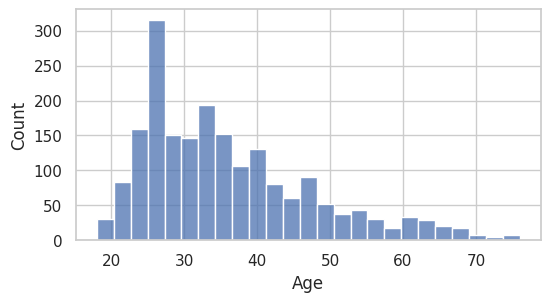

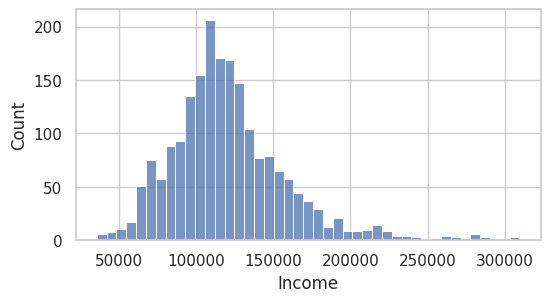

In [22]:
for num in num_col :
  plt.figure(figsize=(6,3))
  sns.histplot(data=df_eda, x=num)

### Insight Histogram

In [24]:
cat_col

['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']

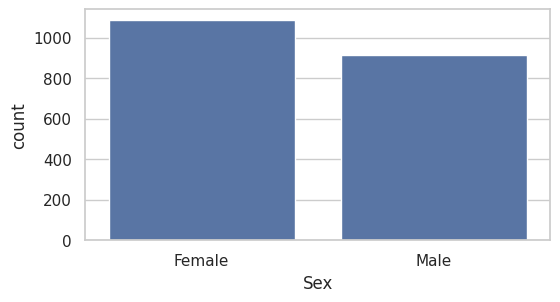

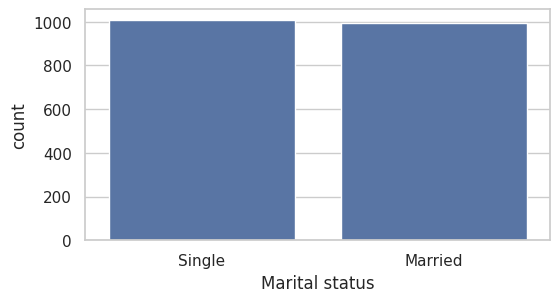

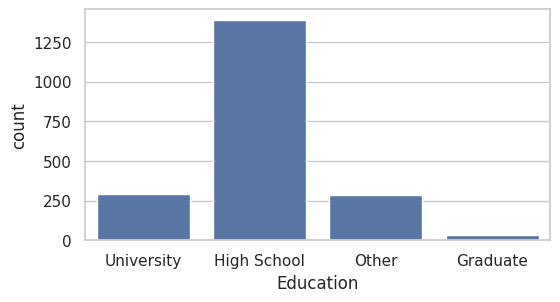

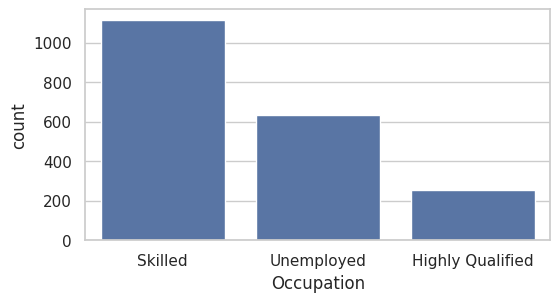

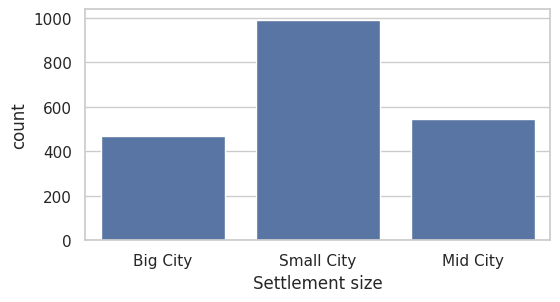

In [25]:
for cat in cat_col :
  plt.figure(figsize=(6,3))
  sns.countplot(data=df_eda, x=cat)

### Insight univariat
- Usia pelanggan berada pada rentang **18–76 tahun**, dengan median sekitar **33 tahun**.
- Pendapatan memiliki distribusi miring ke kanan; sebagian kecil pelanggan mempunyai pendapatan jauh di atas mayoritas.
- Kategori pendidikan terbanyak adalah **High School**.
- Kelompok pekerjaan terbesar adalah **Skilled**, sedangkan ukuran permukiman terbanyak adalah **Small City**.

##EDA Bivariat

In [26]:
df_eda.columns

Index(['Sex', 'Marital status', 'Age', 'Education', 'Income', 'Occupation',
       'Settlement size'],
      dtype='object')

<Axes: xlabel='Age', ylabel='Income'>

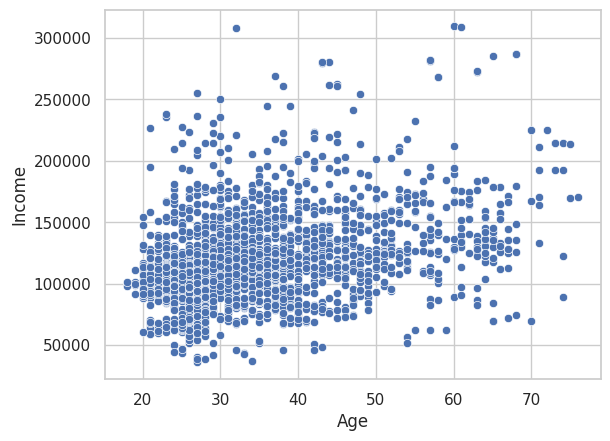

In [27]:
sns.scatterplot(data=df_eda, x='Age', y='Income')

In [28]:
df_eda['Age'].corr(df_eda['Income'])

np.float64(0.3406101637317352)

### Insight bivariat
Korelasi usia dan pendapatan bersifat **positif sedang**. Artinya, pelanggan yang lebih tua cenderung mempunyai pendapatan lebih tinggi, tetapi usia bukan satu-satunya faktor penentu. Distribusi pendapatan juga bergeser menurut pekerjaan, pendidikan, dan ukuran kota.

In [29]:
num_col

['Age', 'Income']

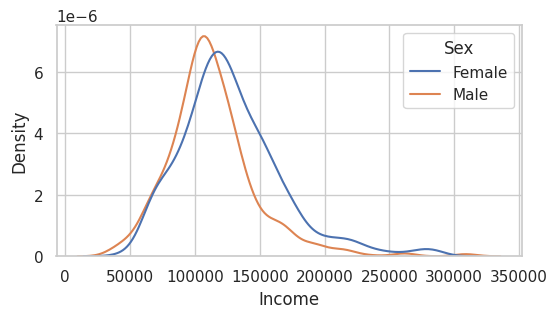

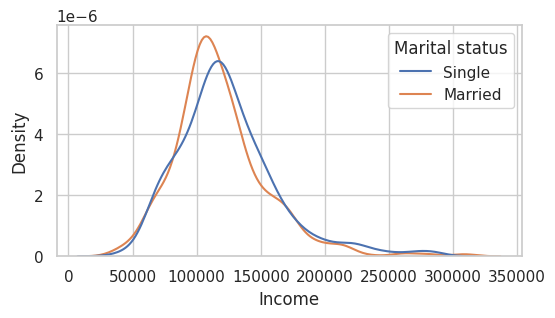

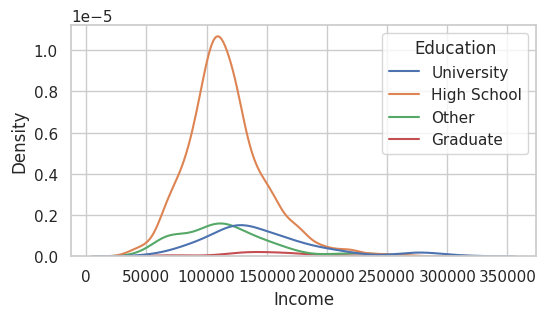

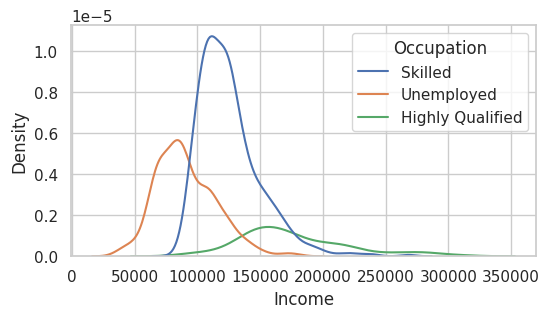

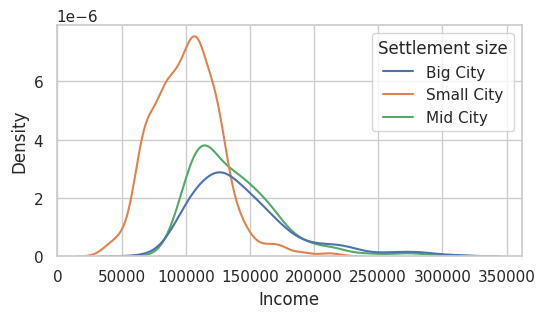

In [31]:
for cat in cat_col :
  plt.figure(figsize=(6,3))
  sns.kdeplot(data=df_eda, x=num, hue=cat)

### Insght Distribution plot

## 7. EDA Multivariat

In [32]:
def bivariate_scatter(x, y, hue, df):
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=x, y=y, data=df, hue=hue, alpha=0.85)

In [34]:
cat_col

['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']

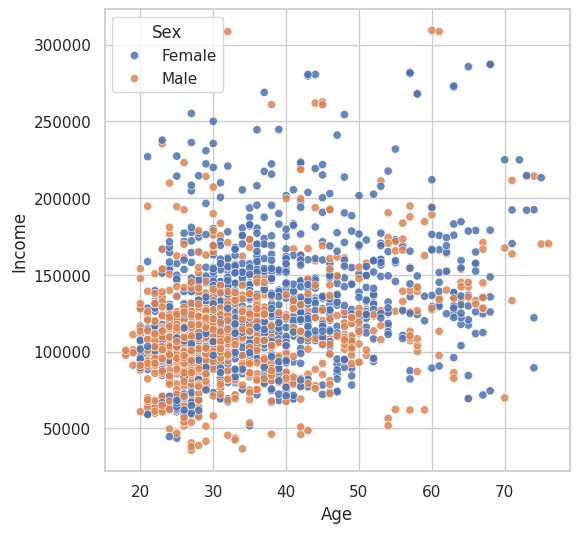

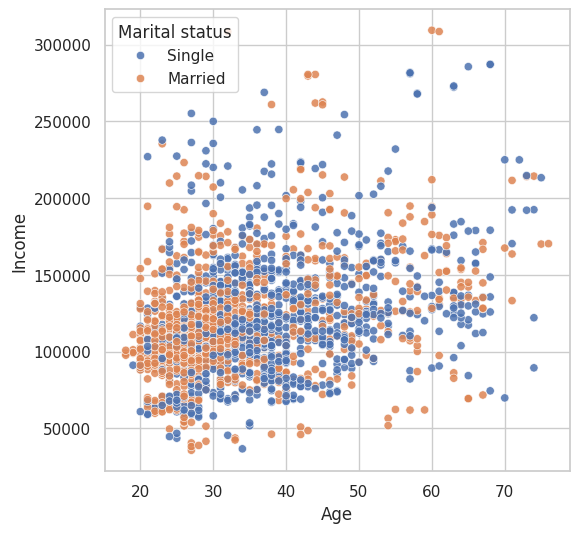

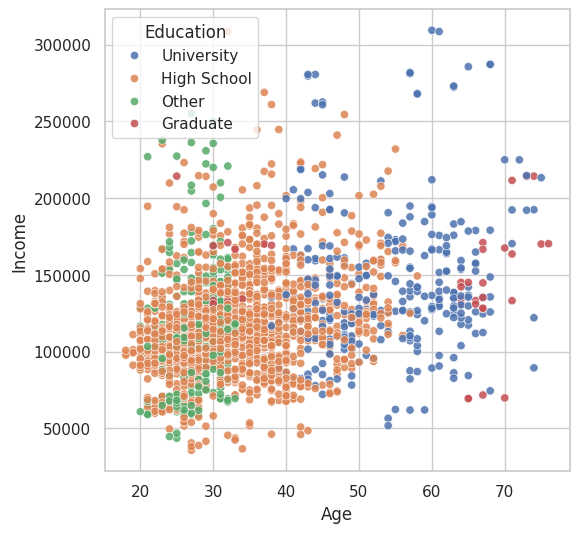

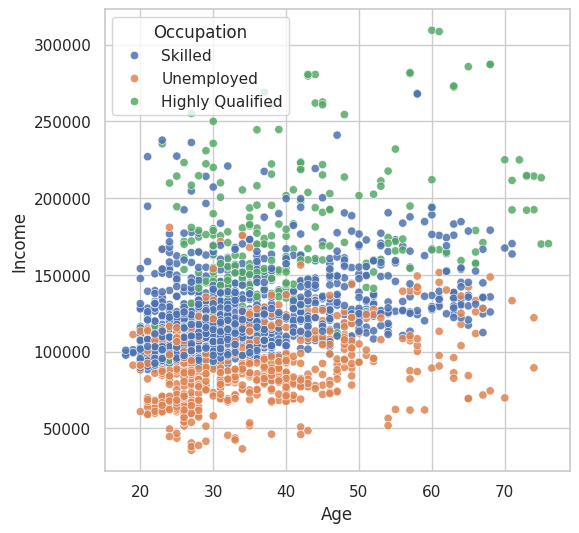

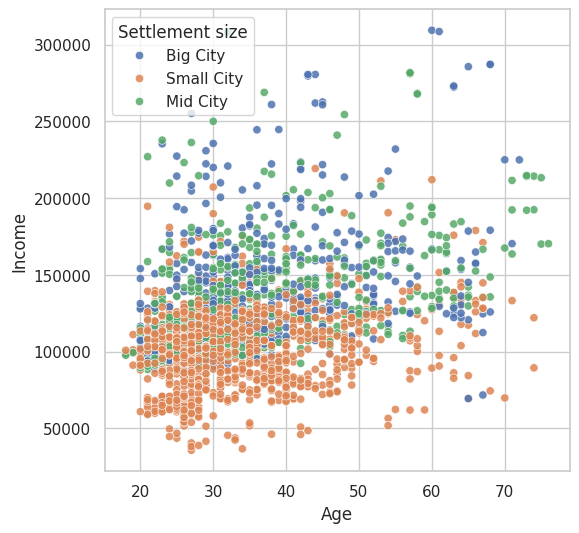

In [33]:
for cat in cat_col :
  bivariate_scatter('Age','Income',cat, df_eda)

###Insight Multivariat

##Revenue perusahaan

ciri - ciri income tinggi



1.   Big City
2.   Skill Work
3.   Highly Qualifed



###Analisis revenue
Pelanggan yang paling potensial untuk program premium umumnya berasal dari kombinasi berikut:

- pekerjaan **Highly Qualified** atau **Skilled**;
- tinggal di **Big City** atau **Mid City**;
- tingkat pendidikan lebih tinggi;
- berada pada kelompok usia produktif matang hingga senior dengan daya beli lebih kuat.

**Implikasi strategi:** tawarkan produk premium, bundling bernilai tinggi, program loyalitas berjenjang, dan komunikasi berbasis kualitas/kenyamanan. Pelanggan berpendapatan lebih rendah tetap relevan, tetapi lebih cocok untuk produk entry-level, promosi harga, dan skema cicilan.

In [35]:
customer_info

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...
1995,1,0,47,1,123525,0,0
1996,1,1,27,1,117744,1,0
1997,0,0,31,0,86400,0,0
1998,1,1,24,1,97968,0,0


In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X= scaler.fit_transform(customer_info)

In [38]:
X

array([[-0.91739884, -0.99302433,  2.65361447, ...,  0.09752361,
         0.29682303,  1.552326  ],
       [ 1.09003844,  1.00702467, -1.18713209, ...,  0.78265438,
         0.29682303,  1.552326  ],
       [-0.91739884, -0.99302433,  1.11731585, ..., -0.83320224,
        -1.26952539, -0.90972951],
       ...,
       [-0.91739884, -0.99302433, -0.41898277, ..., -0.90695688,
        -1.26952539, -0.90972951],
       [ 1.09003844,  1.00702467, -1.01643224, ..., -0.60332923,
        -1.26952539, -0.90972951],
       [-0.91739884, -0.99302433, -0.93108232, ..., -1.3789866 ,
        -1.26952539, -0.90972951]])

# Clustering

Jumlah K Optimal

In [39]:
from sklearn.cluster import KMeans

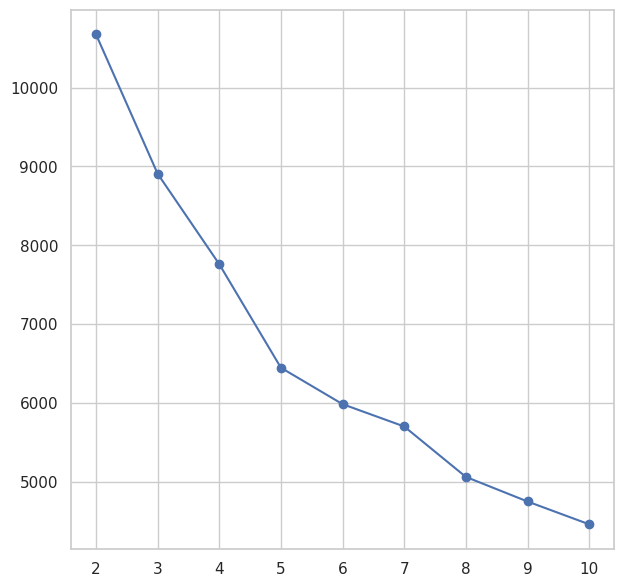

In [40]:
clusters_range = [2,3,4,5,6,7,8,9,10]
inertia = []
for c in clusters_range:
  kmeans = KMeans(n_clusters= c, random_state=42, init="k-means++").fit(X) #Training cluster ke data scaling
  inertia.append(kmeans.inertia_)
#Membuat plot elbow
plt.figure(figsize=(7,7))
plt.plot(clusters_range, inertia, marker='o')

In [41]:
inertia

[10674.294049383008,
 8907.898028914933,
 7761.47418098931,
 6449.492103746891,
 5988.100866179876,
 5705.051575716004,
 5066.316782614308,
 4754.754386186656,
 4465.748848114483]

In [44]:
from sklearn.metrics import silhouette_score
import plotly.express as px
cluster_range = list(range(2, 11))
seeds = [0, 21, 42, 87, 100]
results = []
for seed in seeds:
    for k in cluster_range:
        km = KMeans(n_clusters=k, random_state=seed, init='k-means++', n_init=10)
        km.fit(X)
        score = silhouette_score(X, km.labels_)
        results.append({'n_clusters': k, 'seed': seed, 'silhouette_score': round(score, 4)})
result_df = pd.DataFrame(results)
pivot = result_df.pivot_table(index='n_clusters', columns='seed', values='silhouette_score')
fig = px.imshow(
    pivot,
    labels=dict(x='Random Seed', y='Number of Clusters', color='Silhouette Score'),
    title='<b>Silhouette Score Heatmap — Higher Score = Better Separation</b>',
    color_continuous_scale='RdYlGn',
    text_auto=True, aspect='auto'
)
fig.update_layout(template='plotly_white', height=420)
fig.show()
avg_scores = result_df.groupby('n_clusters')['silhouette_score'].mean().round(4)
print('Average Silhouette Score per K:')
print(avg_scores.to_string())

Average Silhouette Score per K:
n_clusters
2    0.25
3    0.27
4    0.27
5    0.25
6    0.26
7    0.26
8    0.27
9    0.30
10   0.30


### Insight Kurva elbow dan Silhouette Keputusan jumlah cluster

Kurva elbow menunjukkan penurunan inertia yang mulai melandai di sekitar **k = 5**. Silhouette score memang dapat meningkat kembali pada jumlah cluster yang lebih besar, tetapi terlalu banyak cluster akan memperumit interpretasi dan strategi bisnis.

Karena itu digunakan **5 cluster** sebagai kompromi antara:
- kekompakan cluster;
- pemisahan antarcluster;
- stabilitas;
- kemudahan interpretasi dan implementasi strategi.

# Reduksi Dimensi

In [45]:
pd.DataFrame(X, columns=df.columns)

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,-0.92,-0.99,2.65,1.60,0.10,0.30,1.55
1,1.09,1.01,-1.19,-0.06,0.78,0.30,1.55
2,-0.92,-0.99,1.12,-0.06,-0.83,-1.27,-0.91
3,-0.92,-0.99,0.78,-0.06,1.33,0.30,0.32
4,-0.92,-0.99,1.46,-0.06,0.74,0.30,0.32
...,...,...,...,...,...,...,...
1995,1.09,-0.99,0.95,-0.06,0.07,-1.27,-0.91
1996,1.09,1.01,-0.76,-0.06,-0.08,0.30,-0.91
1997,-0.92,-0.99,-0.42,-1.73,-0.91,-1.27,-0.91
1998,1.09,1.01,-1.02,-0.06,-0.60,-1.27,-0.91


In [46]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)
X_pca_df = pd.DataFrame(data=X_pca, columns=['X1','X2','X3'])
X_pca_df

,X1,X2,X3
0,2.51,0.83,2.17
1,0.34,0.60,-2.21
2,-0.65,-0.68,2.28
3,1.71,-0.58,0.73
4,1.63,-0.44,1.24
...,...,...,...
1995,-0.87,0.30,1.44
1996,-1.11,0.79,-1.08
1997,-1.45,-2.24,0.90
1998,-2.24,0.63,-0.53


In [47]:
kmeans = KMeans(n_clusters=6, random_state=42, init="k-means++").fit(X_pca)
labels = kmeans.labels_
X_pca_df['Labels'] = labels
X_pca_df

,X1,X2,X3,Labels
0,2.51,0.83,2.17,3
1,0.34,0.60,-2.21,2
2,-0.65,-0.68,2.28,4
3,1.71,-0.58,0.73,5
4,1.63,-0.44,1.24,5
...,...,...,...,...
1995,-0.87,0.30,1.44,4
1996,-1.11,0.79,-1.08,2
1997,-1.45,-2.24,0.90,4
1998,-2.24,0.63,-0.53,1


In [48]:
X_pca_df['Labels'].value_counts()

,count
Labels,
2,539
4,346
0,342
5,269
1,257
3,247


In [49]:
import plotly.express as px
fig = px.scatter_3d(X_pca_df, x='X1', y='X2', z='X3', color=X_pca_df['Labels'])
fig.show()

### Insight Scatter 3d

## 14. Profiling customer per cluster

In [50]:
df_eda
df_eda['Cluster']=  kmeans.labels_

In [51]:
df_eda

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Cluster
0,Female,Single,67,University,124670,Skilled,Big City,3
1,Male,Married,22,High School,150773,Skilled,Big City,2
2,Female,Single,49,High School,89210,Unemployed,Small City,4
3,Female,Single,45,High School,171565,Skilled,Mid City,5
4,Female,Single,53,High School,149031,Skilled,Mid City,5
...,...,...,...,...,...,...,...,...
1995,Male,Single,47,High School,123525,Unemployed,Small City,4
1996,Male,Married,27,High School,117744,Skilled,Small City,2
1997,Female,Single,31,Other,86400,Unemployed,Small City,4
1998,Male,Married,24,High School,97968,Unemployed,Small City,1


In [52]:
df_eda.groupby(['Cluster','Marital status']).size().reset_index()

,Cluster,Marital status,0
0,0,Single,342
1,1,Married,245
2,1,Single,12
3,2,Married,506
4,2,Single,33
5,3,Married,167
6,3,Single,80
7,4,Married,41
8,4,Single,305
9,5,Married,34


In [53]:
df_eda.groupby(['Cluster','Sex']).size().reset_index()

,Cluster,Sex,0
0,0,Female,342
1,1,Female,6
2,1,Male,251
3,2,Female,123
4,2,Male,416
5,3,Female,130
6,3,Male,117
7,4,Female,220
8,4,Male,126
9,5,Female,265


In [54]:
df_eda.groupby(['Cluster','Occupation']).size().reset_index()

,Cluster,Occupation,0
0,0,Highly Qualified,6
1,0,Skilled,315
2,0,Unemployed,21
3,1,Skilled,4
4,1,Unemployed,253
5,2,Highly Qualified,31
6,2,Skilled,498
7,2,Unemployed,10
8,3,Highly Qualified,73
9,3,Skilled,144


In [55]:
df_eda.groupby(['Cluster','Settlement size']).size().reset_index()

,Cluster,Settlement size,0
0,0,Big City,83
1,0,Mid City,157
2,0,Small City,102
3,1,Small City,257
4,2,Big City,111
5,2,Mid City,197
6,2,Small City,231
7,3,Big City,91
8,3,Mid City,103
9,3,Small City,53


In [56]:
df_eda.groupby(['Cluster'])['Age'].mean()

,Age
Cluster,
0,34.39
1,33.62
2,27.95
3,55.94
4,34.52
5,39.36


In [57]:
df_eda.groupby(['Cluster'])['Income'].mean()

,Income
Cluster,
0,"121,445.29"
1,"89,699.27"
2,"119,169.57"
3,"160,416.62"
4,"86,768.79"
5,"161,503.86"


## 15. **Jawaban Profiling Cluster 0–4 dan Strategi**

### **Cluster 0 — Career Independent Women**
- **Ukuran:** 513 pelanggan (25,7%).
- **Ciri utama:** hampir seluruhnya perempuan dan single; usia rata-rata sekitar 37 tahun; pendapatan rata-rata sekitar $143 ribu; mayoritas skilled; banyak tinggal di big city atau mid city.
- **Nilai bisnis:** daya beli tinggi dan cenderung mandiri dalam keputusan pembelian.
- **Strategi:** produk premium, loyalty tier, personalized recommendation, layanan cepat, dan kampanye bertema karier serta kenyamanan.

### **Cluster 1 — Budget-Conscious Family Men**
- **Ukuran:** 259 pelanggan (13,0%).
- **Ciri utama:** hampir seluruhnya laki-laki menikah; usia rata-rata sekitar 34 tahun; pendapatan rata-rata sekitar $90 ribu; mayoritas unemployed dan seluruhnya tinggal di small city.
- **Nilai bisnis:** sensitif terhadap harga dan membutuhkan manfaat yang konkret untuk keluarga.
- **Strategi:** paket hemat keluarga, diskon volume, cicilan, cashback kebutuhan pokok, dan komunikasi yang menekankan value for money.

### **Cluster 2 — Young Skilled Family Men**
- **Ukuran:** 522 pelanggan (26,1%).
- **Ciri utama:** mayoritas laki-laki menikah; merupakan cluster termuda dengan usia rata-rata sekitar 28 tahun; pendapatan sekitar $119 ribu; lebih dari 90% bekerja sebagai skilled; tersebar di small, mid, dan big city.
- **Nilai bisnis:** kelompok berkembang dengan potensi kenaikan pendapatan dan lifetime value tinggi.
- **Strategi:** program upgrade bertahap, produk digital, bundling keluarga muda, referral program, dan penawaran berbasis pertumbuhan karier.

### **Cluster 3 — Established Affluent Adults**
- **Ukuran:** 248 pelanggan (12,4%).
- **Ciri utama:** usia tertinggi, rata-rata sekitar 56 tahun; pendapatan tertinggi sekitar $162 ribu; mayoritas menikah dan berpendidikan university; pekerjaan didominasi skilled serta highly qualified; banyak berada di mid/big city.
- **Nilai bisnis:** segmen paling kuat untuk produk bernilai tinggi dan layanan premium.
- **Strategi:** relationship marketing, layanan prioritas, produk premium dengan jaminan kualitas, konsultasi personal, serta program retensi khusus pelanggan bernilai tinggi.

### **Cluster 4 — Independent Value Seekers**
- **Ukuran:** 458 pelanggan (22,9%).
- **Ciri utama:** mayoritas perempuan dan single; usia rata-rata sekitar 35 tahun; pendapatan sekitar $94 ribu; sebagian besar unemployed; hampir seluruhnya tinggal di small city.
- **Nilai bisnis:** tetap potensial apabila hambatan harga dan akses diturunkan.
- **Strategi:** produk entry-level, promo terbatas, paket fleksibel, edukasi manfaat produk, kanal penjualan digital berbiaya rendah, dan program loyalitas sederhana.

> Nama cluster merupakan label bisnis yang dibuat dari pola dominan. Label tersebut bukan identitas mutlak setiap individu di dalam cluster.

##**Jawaban Metode clustering lain**

In [65]:
# A. Agglomerative Clustering dengan jumlah cluster yang sama agar adil dibandingkan.
agglomerative = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agglomerative.fit_predict(X_pca)

# B. DBSCAN: parameter dipilih sebagai demonstrasi clustering berbasis kepadatan.
dbscan = DBSCAN(eps=0.90)
db_labels = dbscan.fit_predict(X_pca)

# Evaluasi DBSCAN dilakukan pada titik non-noise.
non_noise_mask = db_labels != -1
n_dbscan_clusters = len(set(db_labels[non_noise_mask]))
noise_ratio = 1 - non_noise_mask.mean()

comparison_rows = [
    {
        'Metode': 'K-Means (k=5)',
        'Jumlah Cluster': len(np.unique(labels)),
        'Noise (%)': 0.0,
        'Silhouette': silhouette_score(X_pca, labels),
        'Davies-Bouldin': davies_bouldin_score(X_pca, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_pca, labels),
    },
    {
        'Metode': 'Agglomerative Ward (k=5)',
        'Jumlah Cluster': len(np.unique(agg_labels)),
        'Noise (%)': 0.0,
        'Silhouette': silhouette_score(X_pca, agg_labels),
        'Davies-Bouldin': davies_bouldin_score(X_pca, agg_labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_pca, agg_labels),
    },
]

if n_dbscan_clusters >= 2:
    comparison_rows.append({
        'Metode': 'DBSCAN (non-noise)',
        'Jumlah Cluster': n_dbscan_clusters,
        'Noise (%)': noise_ratio * 100,
        'Silhouette': silhouette_score(X_pca[non_noise_mask], db_labels[non_noise_mask]),
        'Davies-Bouldin': davies_bouldin_score(X_pca[non_noise_mask], db_labels[non_noise_mask]),
        'Calinski-Harabasz': calinski_harabasz_score(X_pca[non_noise_mask], db_labels[non_noise_mask]),
    })

method_comparison = pd.DataFrame(comparison_rows).round(4)
display(method_comparison)

print('Jumlah anggota Agglomerative:')
display(pd.Series(agg_labels).value_counts().sort_index().rename('Customers').to_frame())
print('Jumlah anggota DBSCAN termasuk label -1 sebagai noise:')
display(pd.Series(db_labels).value_counts().sort_index().rename('Customers').to_frame())

,Metode,Jumlah Cluster,Noise (%),Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means (k=5),6,0.00,0.33,1.09,906.38
1,Agglomerative Ward (k=5),5,0.00,0.35,0.98,847.57
2,DBSCAN (non-noise),6,0.70,0.24,1.31,330.01


Jumlah anggota Agglomerative:


,Customers
0,688
1,669
2,238
3,314
4,91


Jumlah anggota DBSCAN termasuk label -1 sebagai noise:


,Customers
-1,14
0,81
1,568
2,748
3,572
4,10
5,7


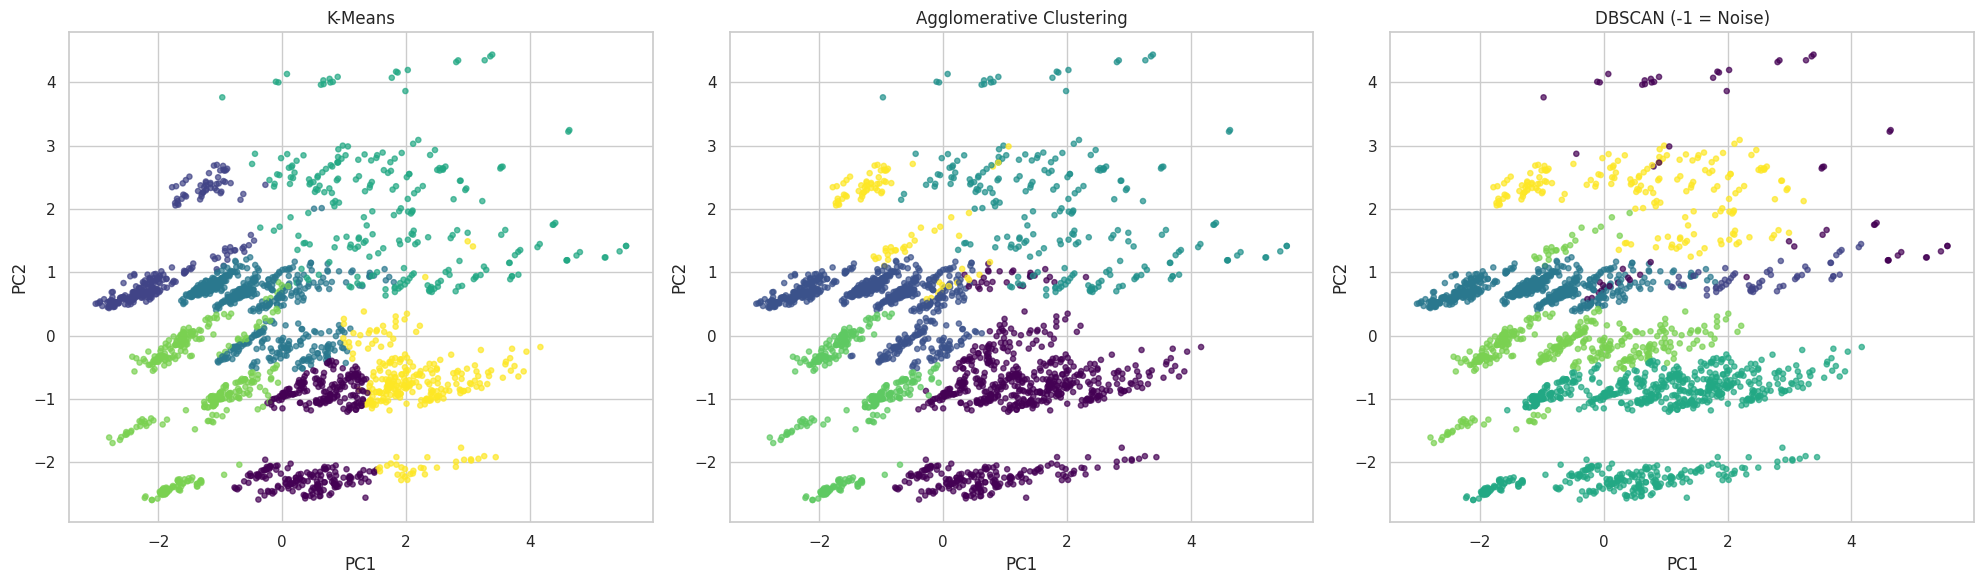

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=14, alpha=0.7)
axes[0].set_title('K-Means')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='viridis', s=14, alpha=0.7)
axes[1].set_title('Agglomerative Clustering')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='viridis', s=14, alpha=0.7)
axes[2].set_title('DBSCAN (-1 = Noise)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

### Kesimpulan perbandingan metode

- **Agglomerative Clustering** menghasilkan kualitas pemisahan yang sangat dekat, bahkan silhouette sedikit lebih tinggi pada data ini. Namun ukuran clusternya lebih timpang dan prosesnya lebih berat untuk dataset besar.
- **DBSCAN** dapat menemukan noise serta bentuk cluster non-sferis, tetapi sangat sensitif terhadap `eps` dan `min_samples`. Pada data ini, hasilnya tidak menghasilkan lima segmen bisnis yang sama stabilnya.
- **K-Means tetap dipilih sebagai model utama** karena cepat, mudah dijelaskan, ukuran segmennya relatif seimbang, dan profil tiap cluster mudah diterjemahkan menjadi strategi pemasaran.